In [1]:
%matplotlib inline


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score

In [3]:
df1 = pd.read_csv('cold_chain_telemetry (1).csv.xls')
df1

,carrier_id,truck_age_years,trip_duration_hours,current_cargo_volume,door_status,compressor_status,ambient_external_temp_c,battery_voltage,compressor_current_draw,engine_vibration_hz,coolant_pressure_psi,cargo_internal_temp_c,failure_imminent
0,FROST_LOGISTICS,7,181,89,0,1,-4.8,10.4,51.5,40.4,38.5,-15.5,1
1,FROST_LOGISTICS,11,78,33,1,1,-6.1,14.5,25.9,21.2,37.4,-18.2,0
2,ARCTIC_TRANSIT,2,83,24,0,0,9.8,14.2,1.1,20.9,47.7,-19.2,0
3,ARCTIC_TRANSIT,4,161,75,1,1,8.2,13.9,33.1,34.0,37.0,-16.6,0
4,POLAR_FREIGHT,12,60,45,1,1,2.8,13.5,30.7,23.5,53.2,-18.3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,FROST_LOGISTICS,13,44,57,1,1,21.7,13.3,30.1,41.5,52.8,-16.4,0
9996,FROST_LOGISTICS,2,28,68,1,1,22.2,14.3,30.7,44.1,38.9,-18.6,0
9997,FROST_LOGISTICS,8,67,72,1,1,1.4,14.0,30.5,32.3,48.2,-18.8,0
9998,ARCTIC_TRANSIT,6,102,82,0,1,-0.9,13.7,15.1,36.5,33.8,-20.0,0


In [85]:
profile = ProfileReport(df1)
profile.to_file("report1.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 704.21it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
df1.isnull().sum()

carrier_id                 0
truck_age_years            0
trip_duration_hours        0
current_cargo_volume       0
door_status                0
compressor_status          0
ambient_external_temp_c    0
battery_voltage            0
compressor_current_draw    0
engine_vibration_hz        0
coolant_pressure_psi       0
cargo_internal_temp_c      0
failure_imminent           0
dtype: int64

In [5]:
X_train, X_test, y_train, y_test = train_test_split(df1.drop(columns = ['failure_imminent']),
                                                   df1['failure_imminent'],
                                                   test_size = 0.3,
                                                   stratify = df1['failure_imminent'],
                                                   random_state = 42)


In [6]:
X_train.head()

,carrier_id,truck_age_years,trip_duration_hours,current_cargo_volume,door_status,compressor_status,ambient_external_temp_c,battery_voltage,compressor_current_draw,engine_vibration_hz,coolant_pressure_psi,cargo_internal_temp_c
5336,FROST_LOGISTICS,6,53,26,1,1,36.0,14.0,28.9,43.3,48.5,-17.4
860,ARCTIC_TRANSIT,3,101,99,1,1,23.5,14.2,40.5,51.3,51.2,-2.9
4250,ARCTIC_TRANSIT,7,21,67,0,0,12.3,14.1,1.6,34.7,49.6,-19.3
7685,ARCTIC_TRANSIT,1,83,53,0,1,-1.2,13.9,31.5,38.5,22.8,-12.1
5580,FROST_LOGISTICS,12,47,22,0,0,25.1,13.4,1.1,30.1,37.7,-19.3


In [7]:
for i, col in enumerate(X_train.columns):
    print(i, col)

0 carrier_id
1 truck_age_years
2 trip_duration_hours
3 current_cargo_volume
4 door_status
5 compressor_status
6 ambient_external_temp_c
7 battery_voltage
8 compressor_current_draw
9 engine_vibration_hz
10 coolant_pressure_psi
11 cargo_internal_temp_c


In [8]:
trf0 =ColumnTransformer([
    ('carrier_id',OneHotEncoder(handle_unknown='ignore'),[0])
],remainder='passthrough')

In [138]:
# trf1 = ColumnTransformer([
#     ('scale', MinMaxScaler(), [4,5,6,9,10,11,12,13,14])
# ], remainder = 'passthrough')

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

trf2 =  LogisticRegression(
        max_iter=5,
        class_weight='balanced',
        random_state=42
    )

In [10]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.model_selection import cross_val_score

pipe = make_pipeline(trf0, trf2)
score = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
print(score)

[0.98935587 0.98629677 0.98931973 0.9861267  0.99069303]


In [11]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('carrier_id', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

In [12]:
y_prob = pipe.predict_proba(X_train)[:,1]
y_pred = (y_prob >= 0.50).astype(int)
acc = accuracy_score(y_train, y_pred)
print(acc)

0.9398571428571428


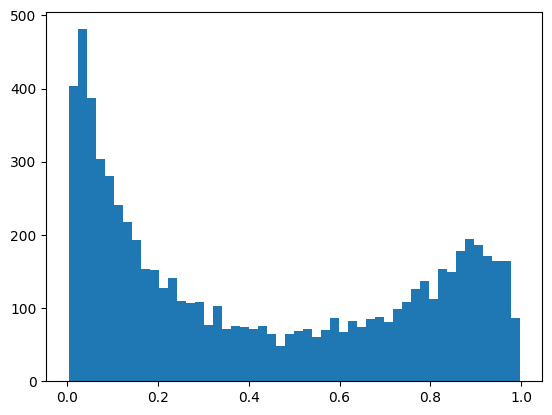

In [13]:
plt.hist(y_prob, bins=50)
plt.show()

In [14]:
print(classification_report(y_train, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      4200
           1       0.91      0.94      0.93      2800

    accuracy                           0.94      7000
   macro avg       0.94      0.94      0.94      7000
weighted avg       0.94      0.94      0.94      7000



In [15]:
import joblib
joblib.dump(pipe,'pipe.pkl')

['pipe.pkl']